In [1]:
import os
import sys

os.environ["CUDA_LAUNCH_BLOCKING"] = "1" # for debugging

# add local project to module path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt
from src.model import Dequant, DequantConfig

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [2]:
def plot_pattern(pattern, *, ax=None, instruments=["Kick", "Snare"]):
    seq_len, num_instruments, _hov = pattern.shape
    assert len(instruments) == num_instruments, "Number of instruments in the pattern does not match the number of instrument labels"

    # create a meshgrid that is displayed in the background
    xs = np.arange(seq_len)
    ys = np.arange(num_instruments)
    mx, my = np.meshgrid(xs, ys)

    if ax is None:
        ax = plt.subplot(1, 1, 1)

    # plot the background grid
    ax.scatter(mx, my, s=1000, facecolors="none", edgecolors="black", linestyle="--", alpha=0.3)

    # plot the actual pattern dots
    ax.scatter(
        mx + pattern[mx, my, 1], # apply the offset
        my,
        s=1000,
        edgecolors="none",
        c=pattern[mx, my, 2], # use velocity as color
        cmap="binary", # 0 = white, 1 = black
        alpha=pattern[mx, my, 0] > 0.5, # use hits as alpha mask
    )

    ax.set_xbound(xs[0] - 0.5, xs[-1] + 0.5)
    ax.set_xticks(xs)

    ax.set_ybound(ys[0] - 0.5, ys[-1] + 0.5)
    ax.set_yticks(ys)
    ax.set_yticklabels(instruments)

Training...
Epoch 0, Loss: 0.183528
Epoch 100, Loss: 0.084520
Epoch 200, Loss: 0.038023
Epoch 300, Loss: 0.026423
Epoch 400, Loss: 0.020391
Epoch 500, Loss: 0.019768
Epoch 600, Loss: 0.019593
Epoch 700, Loss: 0.019513
Epoch 800, Loss: 0.019471
Epoch 900, Loss: 0.019447


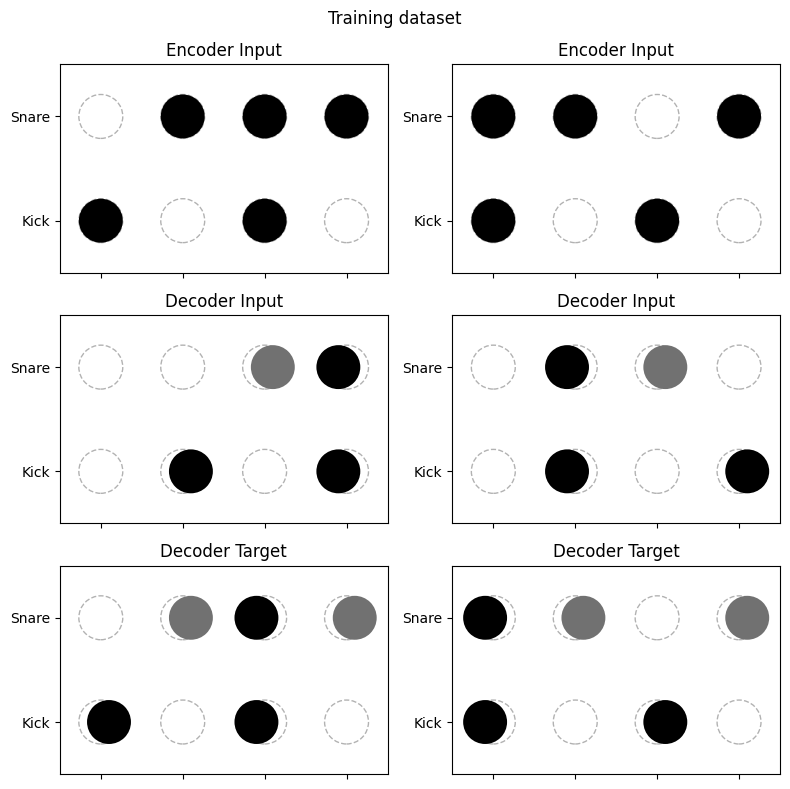

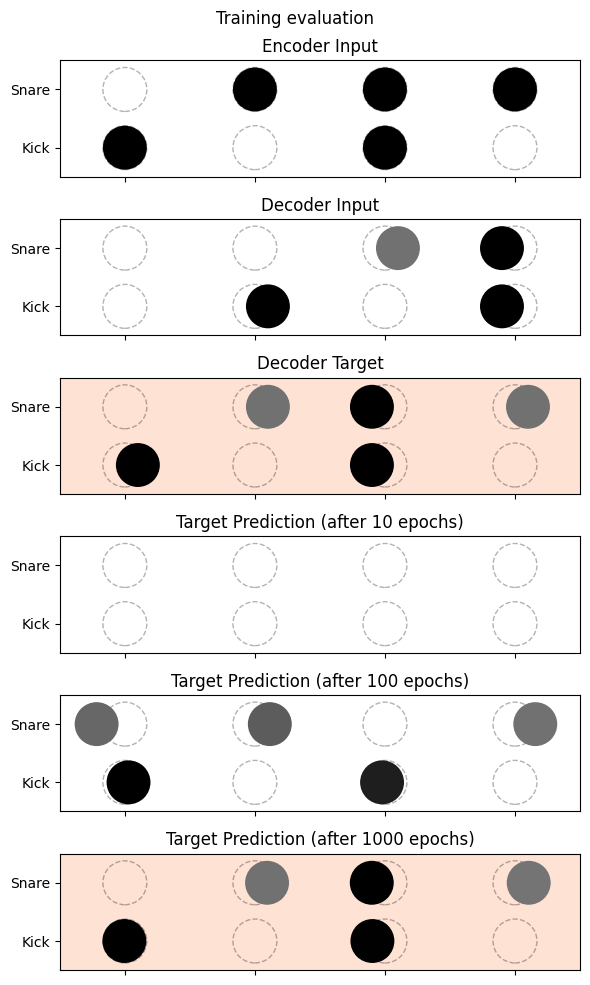

In [3]:
# Training example
# Dataset shape: (batch, seq_len, instrument, hov=3)
dataset_input = torch.tensor([
    [
        [[1.0, 0.0, 1.0], [0.0, 0.0, 0.0]],
        [[0.0, 0.0, 0.0], [1.0, 0.0, 1.0]],
        [[1.0, 0.0, 1.0], [1.0, 0.0, 1.0]],
        [[0.0, 0.0, 0.0], [1.0, 0.0, 1.0]],
    ],
    [
        [[1.0, 0.0, 1.0], [1.0, 0.0, 1.0]],
        [[0.0, 0.0, 0.0], [1.0, 0.0, 1.0]],
        [[1.0, 0.0, 1.0], [0.0, 0.0, 0.0]],
        [[0.0, 0.0, 0.0], [1.0, 0.0, 1.0]],
    ],
])
dataset_target = torch.tensor([
    [
        [[1.0, 0.1, 0.9], [0.0, 0.0, 0.0]],
        [[0.0, 0.0, 0.0], [1.0, 0.1, 0.5]],
        [[1.0, -0.1, 0.9], [1.0, -0.1, 0.9]],
        [[0.0, 0.0, 0.0], [1.0, 0.1, 0.5]],
    ],
    [
        [[1.0, -0.1, 0.9], [1.0, -0.1, 0.9]],
        [[0.0, 0.0, 0.0], [1.0, 0.1, 0.5]],
        [[1.0, 0.1, 0.9], [0.0, 0.0, 0.0]],
        [[0.0, 0.0, 0.0], [1.0, 0.1, 0.5]],
    ],
])

encoder_input = dataset_input
decoder_input = torch.cat([
    torch.zeros(2, 1, 2, 3),  # Start token
    dataset_target[:, :-1]  # Shift right along the seq_len dimension
], dim=1)
decoder_target = dataset_target

# Create a basic optimizer
model = Dequant(DequantConfig(max_seq_len=4, num_instruments=2))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

eval_epochs = [10, 100, 1000]
eval_encin = encoder_input[0]
eval_decin = decoder_input[0]
eval_dectar = decoder_target[0]
eval_predictions = []

print("Training...")
for epoch in range(1000):
    # use the whole dataset as a single batch
    output = model(encoder_input, decoder_input)
    loss = criterion(output, decoder_target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    # Run evaluation on certain epochs
    for eval_epoch in eval_epochs:
        if epoch == eval_epoch - 1:
            with torch.no_grad():
                eval_predictions.append(model.forward(eval_encin.unsqueeze(0), eval_decin.unsqueeze(0))[0].detach())



# Plot the dataset
fig, axes = plt.subplots(3, len(dataset_input))
fig.set_size_inches(8, 8)

for encin, decin, dectar, ax1, ax2, ax3 in zip(encoder_input, decoder_input, decoder_target, *axes):
    plot_pattern(encin.numpy(), ax=ax1)
    ax1.set_title("Encoder Input")
    ax1.set_xticklabels([])

    plot_pattern(decin.numpy(), ax=ax2)
    ax2.set_title("Decoder Input")
    ax2.set_xticklabels([])

    plot_pattern(dectar.numpy(), ax=ax3)
    ax3.set_title("Decoder Target")
    ax3.set_xticklabels([])

fig.suptitle("Training dataset")
fig.tight_layout()
fig.savefig("output/modelv2_dataset.svg")


# Plot the evaluation
fig, (ax1, ax2, ax3, *eval_axes) = plt.subplots(3 + len(eval_epochs))
fig.set_size_inches(6, 10)

plot_pattern(eval_encin.numpy(), ax=ax1)
ax1.set_title("Encoder Input")
ax1.set_xticklabels([])

plot_pattern(eval_decin.numpy(), ax=ax2)
ax2.set_title("Decoder Input")
ax2.set_xticklabels([])

plot_pattern(eval_dectar.numpy(), ax=ax3)
ax3.set_title("Decoder Target")
ax3.set_xticklabels([])
ax3.set_facecolor("#FC7229")
ax3.patch.set_alpha(0.2)

for epoch, prediction, ax in zip(eval_epochs, eval_predictions, eval_axes):
    plot_pattern(prediction.numpy(), ax=ax)
    ax.set_title(f"Target Prediction (after {epoch} epochs)")
    ax.set_xticklabels([])

    if epoch == 1000:
        ax.set_facecolor("#FC7229")
        ax.patch.set_alpha(0.2)

fig.suptitle("Training evaluation")
fig.tight_layout()
fig.savefig("output/modelv2_evaluation.svg")